In [ ]:
# @title 0) Overview & Assignment Context
"""
Prompt Engineering Experiments — Multi-Provider, Classroom-Proof (Colab)

GOALS
• Understand how prompt design influences LLM outputs (accuracy, diversity, hallucinations).
• Design and compare multiple prompt templates for summarization & QA.
• Evaluate with automatic metrics (overlap for summarization; EM/F1 for QA) and visualizations.
• Produce artifacts + 2–3 page reflection.

WHAT THIS NOTEBOOK DOES
1) Safe setup (no dependency pinning conflicts).
2) Configure providers (HF default; optional OpenAI/Claude/Gemini).
3) Step-by-step Hugging Face token guide + secure token entry.
4) Smoke test to confirm access works before the full grid.
5) Unified LLM dispatcher + MOCK fallback (and FORCE_MOCK for offline use).
6) Build dataset, define diverse prompts, run experiments (prompts × models × params).
7) Evaluate on successful generations only; compute success rates.
8) Visualize: success rate, metric bars with legends/labels, cross-model bars, heatmaps.
9) Export a human-eval sample and checklist for your write-up.

TIP
• For “real” curves, set an HF token (or other keys). If you can’t, set FORCE_MOCK=True to run fully offline with meaningful plots.
"""
print("Loaded overview. Scroll down & Run all when ready.")

Loaded overview. Scroll down & Run all when ready.


In [1]:
# @title 1) Environment setup (safe) & optional keys
import os, sys, subprocess

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        __import__(import_name)
        print(f"✓ {pkg} available")
    except Exception:
        print(f"→ Installing {pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        __import__(import_name)
        print(f"✓ {pkg} installed")

# Core utilities (usually preinstalled in Colab); install only if missing
for pkg, imp in [
    ("tqdm","tqdm"),
    ("matplotlib","matplotlib"),
    ("scikit-learn","sklearn"),
    ("requests","requests"),
    ("pandas","pandas"),
    ("numpy","numpy")
]:
    ensure(pkg, imp)

# OPTIONAL: If you already have API keys, you can set them here programmatically
# (Or use the secure getpass in Cell 3 for HF)
# os.environ["OPENAI_API_KEY"]    = "sk-..."
# os.environ["ANTHROPIC_API_KEY"] = "anthropic-..."
# os.environ["GEMINI_API_KEY"]    = "AIza..."
print("\n✅ Setup complete.")

✓ tqdm available
✓ matplotlib available
✓ scikit-learn available
✓ requests available
✓ pandas available
✓ numpy available

✅ Setup complete.


In [12]:
# @title 2) Configure providers, models, and switches
import os

OPENAI_API_KEY     = os.getenv("OPENAI_API_KEY", "")
ANTHROPIC_API_KEY  = os.getenv("ANTHROPIC_API_KEY", "")
GEMINI_API_KEY     = os.getenv("GEMINI_API_KEY", "")
HF_TOKEN           = os.getenv("HF_TOKEN", "")  # will be set in Cell 3 if you use getpass

# Providers (HF default; others auto-enabled if keys are present)
AVAILABLE_PROVIDERS = ["hf"]
if OPENAI_API_KEY:    AVAILABLE_PROVIDERS.append("openai")
if ANTHROPIC_API_KEY: AVAILABLE_PROVIDERS.append("claude")
if GEMINI_API_KEY:    AVAILABLE_PROVIDERS.append("gemini")

print("Detected providers:", AVAILABLE_PROVIDERS)
if "hf" in AVAILABLE_PROVIDERS and not HF_TOKEN:
    print("ℹ️ HF_TOKEN not set yet — use Cell 3 to enter it securely.")

# Default open-source HF models (you can swap for open alternatives if gated)
HF_MODELS = [
    "Qwen/Qwen3.8-27B"
]
# Good open alternatives if you prefer:
# HF_MODELS = ["HuggingFaceH4/zephyr-7b-beta", "google/gemma-7b-it"]

# Optional proprietary models (used only if their keys are set)
OPENAI_MODELS = ["gpt-4o-mini"]
CLAUDE_MODELS = ["claude-3-5-sonnet-20240620"]
GEMINI_MODELS = ["gemini-1.5-flash"]

# Switches:
USE_MOCK_IF_NO_API = True   # if nothing succeeds, run a small MOCK pass so lab completes
FORCE_MOCK         = True  # set True to ignore remote providers and run MOCK-only (offline/grading)

Detected providers: ['hf']


In [8]:
# @title 3) Step-by-Step: Get real HF models working + set token securely
"""
STEP 1 — Create a Hugging Face access token
  • Visit https://huggingface.co → (login) → Settings → Access Tokens → New token
  • Role: “Read”
  • Copy the token (looks like hf_**********). Keep it private.

STEP 2 — (If needed) Accept the model licenses
  • Open each model page while logged in, click Agree/Request access (one-time):
      - https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.3
      - https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct
    (If you skip this, you'll get 403 Forbidden even with a valid token.)

STEP 3 — Set your token securely in this Colab session
  • Run the cell below; paste your token (it won't be printed).
  • You should see: 'HF_TOKEN set: True'
"""

import getpass, os
tok = getpass.getpass("HF token (paste here, then press Enter): ")
os.environ["HF_TOKEN"] = tok.strip()
print("HF_TOKEN set:", bool(os.environ.get("HF_TOKEN")))

HF token (paste here, then press Enter): ··········
HF_TOKEN set: True


In [13]:
# @title 4) Smoke test: verify each selected provider/model once

import os
from huggingface_hub import InferenceClient

print("=== Smoke test ===")
any_success = False

if not FORCE_MOCK:

    if "hf" in AVAILABLE_PROVIDERS:

        token = os.environ.get("HF_TOKEN")

        if not token:
            print("HF: SKIPPED — HF_TOKEN is not set.")

        else:
            for model in HF_MODELS:
                try:
                    client = InferenceClient(
                        model=model,
                        token=token
                    )

                    response = client.chat_completion(
                        messages=[
                            {
                                "role": "user",
                                "content": "Reply with only: OK"
                            }
                        ],
                        max_tokens=10,
                        temperature=0.01
                    )

                    text = response.choices[0].message.content

                    print(
                        f"HF: {model} →",
                        "OK" if text else "FAIL"
                    )

                    if text:
                        any_success = True

                except Exception as e:
                    print(
                        f"HF: {model} → FAIL "
                        f"({type(e).__name__}: {e})"
                    )

else:
    print("FORCE_MOCK=True — remote model smoke test skipped.")
    any_success = True


print("Smoke test success?", any_success)

=== Smoke test ===
FORCE_MOCK=True — remote model smoke test skipped.
Smoke test success? True


In [15]:
# @title 5) Model caller (unified) + MOCK fallback
import json, os
from huggingface_hub import InferenceClient


# ---------------------------------------------------------
# Hugging Face model caller
# ---------------------------------------------------------
def call_hf_model(
    model: str,
    prompt_text: str,
    temperature: float = 0.3,
    max_new_tokens: int = 256,
    top_p: float = 0.9
):
    token = os.environ.get("HF_TOKEN", "")

    if not token:
        return {"text": "[NO_HF_TOKEN]", "error": True}

    try:
        client = InferenceClient(
            model=model,
            token=token
        )

        response = client.chat_completion(
            messages=[
                {
                    "role": "user",
                    "content": prompt_text
                }
            ],
            max_tokens=max_new_tokens,
            temperature=max(temperature, 0.01),
            top_p=top_p
        )

        text = response.choices[0].message.content

        return {
            "text": (text or "").strip(),
            "error": False
        }

    except Exception as e:
        return {
            "text": f"[HF_ERROR] {type(e).__name__}: {e}",
            "error": True
        }


# ---------------------------------------------------------
# OpenAI model caller
# ---------------------------------------------------------
def call_openai_model(
    model: str,
    prompt_text: str,
    temperature: float = 0.3,
    top_p: float = 0.9,
    max_tokens: int = 256
):
    key = os.environ.get("OPENAI_API_KEY", "")

    if not key:
        return {"text": "[NO_OPENAI_API_KEY]", "error": True}

    try:
        from openai import OpenAI

        client = OpenAI(api_key=key)

        resp = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt_text}],
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens
        )

        return {
            "text": resp.choices[0].message.content.strip(),
            "error": False
        }

    except Exception as e:
        return {
            "text": f"[OPENAI_ERROR] {e}",
            "error": True
        }


# ---------------------------------------------------------
# Claude model caller
# ---------------------------------------------------------
def call_claude_model(
    model: str,
    prompt_text: str,
    temperature: float = 0.3,
    top_p: float = 0.9,
    max_tokens: int = 256
):
    key = os.environ.get("ANTHROPIC_API_KEY", "")

    if not key:
        return {"text": "[NO_ANTHROPIC_API_KEY]", "error": True}

    try:
        import anthropic

        client = anthropic.Anthropic(api_key=key)

        message = client.messages.create(
            model=model,
            max_tokens=max_tokens,
            temperature=temperature,
            messages=[
                {"role": "user", "content": prompt_text}
            ]
        )

        parts = getattr(message, "content", [])
        text = ""

        for p in parts:
            if hasattr(p, "text"):
                text += p.text
            elif isinstance(p, dict) and p.get("type") == "text":
                text += p.get("text", "")

        return {
            "text": text.strip(),
            "error": False
        }

    except Exception as e:
        return {
            "text": f"[CLAUDE_ERROR] {e}",
            "error": True
        }


# ---------------------------------------------------------
# Gemini model caller
# ---------------------------------------------------------
def call_gemini_model(
    model: str,
    prompt_text: str,
    temperature: float = 0.3,
    top_p: float = 0.9,
    max_tokens: int = 256
):
    key = os.environ.get("GEMINI_API_KEY", "")

    if not key:
        return {"text": "[NO_GEMINI_API_KEY]", "error": True}

    try:
        import google.generativeai as genai

        genai.configure(api_key=key)

        gmodel = genai.GenerativeModel(model)

        resp = gmodel.generate_content(
            prompt_text,
            generation_config={
                "temperature": temperature,
                "top_p": top_p,
                "max_output_tokens": max_tokens
            }
        )

        text = getattr(resp, "text", None)

        if text is None:
            try:
                text = resp.candidates[0].content.parts[0].text
            except Exception:
                text = str(resp)

        return {
            "text": (text or "").strip(),
            "error": False
        }

    except Exception as e:
        return {
            "text": f"[GEMINI_ERROR] {e}",
            "error": True
        }


# ---------------------------------------------------------
# MOCK fallback — keeps notebook runnable offline
# ---------------------------------------------------------
def call_mock(
    task: str,
    input_text: str = "",
    question: str = "",
    context: str = ""
):
    if task == "summarization":

        sent = (
            (input_text or "")
            .strip()
            .split(".")[0]
            .strip()
        )

        return {
            "text": f"(MOCK) {sent}.",
            "error": False
        }

    if task == "qa":

        ql = (question or "").lower()
        cl = (context or "").lower()

        if "capital of canada" in ql and "ottawa" in cl:
            return {
                "text":
                '{"answer":"Ottawa",'
                '"evidence":"capital of Canada is Ottawa"}',
                "error": False
            }

        if "who planned artemis ii" in ql and "nasa" in cl:
            return {
                "text":
                '{"answer":"NASA",'
                '"evidence":"NASA planned Artemis II"}',
                "error": False
            }

        return {
            "text":
            '{"answer":"CANNOT_ANSWER","evidence":""}',
            "error": False
        }

    return {
        "text": "(MOCK) unsupported task",
        "error": False
    }


# ---------------------------------------------------------
# Unified model caller
# ---------------------------------------------------------
def call_llm(
    provider: str,
    model: str,
    prompt_text: str,
    task: str,
    temperature: float = 0.3,
    top_p: float = 0.9,
    max_tokens: int = 256,
    fields=None
):

    if provider == "hf":
        return call_hf_model(
            model,
            prompt_text,
            temperature=temperature,
            max_new_tokens=max_tokens,
            top_p=top_p
        )

    if provider == "openai":
        return call_openai_model(
            model,
            prompt_text,
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens
        )

    if provider == "claude":
        return call_claude_model(
            model,
            prompt_text,
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens
        )

    if provider == "gemini":
        return call_gemini_model(
            model,
            prompt_text,
            temperature=temperature,
            top_p=top_p,
            max_tokens=max_tokens
        )

    if provider == "mock":
        return call_mock(
            task,
            input_text=(fields or {}).get("input", ""),
            question=(fields or {}).get("question", ""),
            context=(fields or {}).get("context", "")
        )

    return {
        "text": f"[UNKNOWN_PROVIDER] {provider}",
        "error": True
    }


# ---------------------------------------------------------
# Prompt renderer
# ---------------------------------------------------------
def render_prompt(template: str, fields: dict):

    out = template

    for k, v in fields.items():
        out = out.replace(
            "{" + k + "}",
            str(v)
        )

    return out


print("✅ Model caller functions loaded.")

✅ Model caller functions loaded.


In [16]:
# @title 6) Build dataset (Summarization + QA)
import random
random.seed(42)

sum_sources = [
    ("CRISPR enables precise genome editing; it offers potential cures but raises ethical questions.", "science"),
    ("A coastal city invested in seawalls and wetland restoration to reduce storm surge risk.", "climate"),
    ("A startup launched an AI tutor that adapts to each student’s pace and feedback.", "edtech"),
    ("Quantum computers exploit superposition and entanglement for speedups on specific problems.", "quantum"),
    ("A public health campaign raised vaccination rates with personalized text reminders.", "health"),
    ("A new battery chemistry promises higher energy density and faster charging, with safety trade-offs.", "energy"),
    ("An autonomous vehicle pilot expanded to suburbs after fewer disengagements in city tests.", "transport"),
    ("A museum digitized archives, boosting access but raising copyright concerns.", "culture"),
    ("A sports analytics team used player tracking data to optimize defenses.", "sports"),
    ("A city introduced congestion pricing to cut traffic and fund public transit.", "policy")
]

qa_contexts = [
    ("NASA planned Artemis II to return humans to the Moon. The mission will involve a crewed lunar orbit.",
     "Who planned Artemis II?", "NASA"),
    ("CRISPR-Cas9 is a genome editing tool discovered in bacteria. It allows scientists to alter DNA precisely.",
     "What is CRISPR-Cas9 used for?", "genome editing"),
    ("The capital of Canada is Ottawa, while the largest city is Toronto.",
     "What is the capital of Canada?", "Ottawa"),
    ("Photosynthesis converts carbon dioxide and water into glucose and oxygen using sunlight.",
     "What gas do plants release during photosynthesis?", "oxygen"),
    ("Ada Lovelace is widely regarded as the first computer programmer.",
     "Who is considered the first computer programmer?", "Ada Lovelace"),
    ("The Great Barrier Reef lies off the coast of Queensland, Australia.",
     "Where is the Great Barrier Reef located?", "Australia"),
    ("The human heart has four chambers: two atria and two ventricles.",
     "How many chambers does the human heart have?", "four"),
    ("Mount Everest, located in the Himalayas, is Earth’s highest mountain above sea level.",
     "What is the highest mountain above sea level?", "Mount Everest"),
    ("The Treaty of Versailles formally ended World War I.",
     "What treaty ended World War I?", "Treaty of Versailles"),
    ("In machine learning, overfitting occurs when a model memorizes training data and fails to generalize.",
     "What is overfitting?", "failing to generalize")
]

items = []
# ~70 summarization items
for i in range(70):
    src, _ = random.choice(sum_sources)
    v = src
    if random.random() < 0.3:
        v += " Policymakers are evaluating long-term trade-offs."
    if random.random() < 0.2:
        v = v.replace("AI", "artificial intelligence")
    items.append({"id": f"S{i+1}", "task": "summarization", "input": v})

# ~50 QA items
for i in range(50):
    ctx, q, a = random.choice(qa_contexts)
    if random.random() < 0.25:
        ctx += " Recent reviews highlight open challenges and future directions."
    items.append({"id": f"Q{i+1}", "task": "qa", "question": q, "context": ctx, "answer": a})

print(f"Dataset: {len(items)} items –",
      f"{sum(1 for x in items if x['task']=='summarization')} summarization,",
      f"{sum(1 for x in items if x['task']=='qa')} QA.")
print("Example:", items[0])

Dataset: 120 items – 70 summarization, 50 QA.
Example: {'id': 'S1', 'task': 'summarization', 'input': 'A coastal city invested in seawalls and wetland restoration to reduce storm surge risk. Policymakers are evaluating long-term trade-offs.'}


In [18]:
# @title 7) Prompt templates (diverse strategies)
prompt_defs = [
    {
        "id": "baseline_sum",
        "task": "summarization",
        "prompt": "Summarize the following text in one sentence:\n\n{input}"
    },
    {
        "id": "role_sum",
        "task": "summarization",
        "prompt": "You are an expert science journalist. Write a one-sentence summary that captures the key fact and implication:\n\n{input}"
    },
    {
        "id": "cot_sum",
        "task": "summarization",
        "prompt": "Summarize step by step. First, identify the main idea, then compress it into one concise sentence:\n\n{input}"
    },
    {
        "id": "refusal_sum",
        "task": "summarization",
        "prompt": "If the text is unclear or lacks factual information, reply 'Insufficient evidence.' Otherwise, summarize it in one precise sentence:\n\n{input}"
    },
    {
        "id": "qa_strict_json",
        "task": "qa",
        "prompt": (
            "You are a precise reading-comprehension system.\n"
            "Answer strictly in valid JSON of the form:\n"
            "{\"answer\": \"...\", \"evidence\": \"quote from context\"}\n"
            "If the question cannot be answered from the context, output:\n"
            "{\"answer\": \"CANNOT_ANSWER\", \"evidence\": \"\"}\n\n"
            "Context:\n{context}\n\nQuestion:\n{question}\n"
        )
    }
]
print("Templates:", [p["id"] for p in prompt_defs])

Templates: ['baseline_sum', 'role_sum', 'cot_sum', 'refusal_sum', 'qa_strict_json']


In [19]:
# @title 8) Run experiments (grid) with robust fallback

import pandas as pd
import numpy as np
import time
import os

from datetime import datetime
from tqdm import tqdm


stamp = datetime.now().strftime("%Y%m%d_%H%M%S")


# ---------------------------------------------------------
# Decoding settings required for comparison
# ---------------------------------------------------------
TEMPS = [0.0, 0.3]
TOP_P = [0.9]
MAX_TOKENS = [196]


def iter_models():

    if "hf" in AVAILABLE_PROVIDERS:
        for m in HF_MODELS:
            yield ("hf", m)

    if "openai" in AVAILABLE_PROVIDERS:
        for m in OPENAI_MODELS:
            yield ("openai", m)

    if "claude" in AVAILABLE_PROVIDERS:
        for m in CLAUDE_MODELS:
            yield ("claude", m)

    if "gemini" in AVAILABLE_PROVIDERS:
        for m in GEMINI_MODELS:
            yield ("gemini", m)


rows = []
success_any = False

t0 = time.time()


# =========================================================
# REAL MODEL EXPERIMENT
# =========================================================
if not FORCE_MOCK:

    for provider, model in iter_models():

        for p in prompt_defs:

            for temp in TEMPS:

                for top_p in TOP_P:

                    for max_tokens in MAX_TOKENS:

                        relevant_items = [
                            ex for ex in items
                            if ex["task"] == p["task"]
                        ]

                        for ex in tqdm(
                            relevant_items,
                            desc=(
                                f"{provider}:{model} · "
                                f"{p['id']} · T{temp}"
                            )
                        ):

                            if ex["task"] == "summarization":

                                fields = {
                                    "input": ex["input"]
                                }

                            else:

                                fields = {
                                    "question": ex["question"],
                                    "context": ex["context"]
                                }


                            prompt_text = render_prompt(
                                p["prompt"],
                                fields
                            )


                            out = call_llm(
                                provider,
                                model,
                                prompt_text,
                                task=ex["task"],
                                temperature=temp,
                                top_p=top_p,
                                max_tokens=max_tokens,
                                fields=fields
                            )


                            rows.append({
                                "id": ex["id"],
                                "task": ex["task"],
                                "prompt_id": p["id"],
                                "provider": provider,
                                "model": model,
                                "temperature": temp,
                                "top_p": top_p,
                                "max_tokens": max_tokens,
                                "input": ex.get("input", ""),
                                "question": ex.get("question", ""),
                                "context": ex.get("context", ""),
                                "reference": ex.get("answer", ""),
                                "output": out["text"],
                                "error": out["error"]
                            })


                            if not out["error"]:
                                success_any = True


# =========================================================
# MOCK FALLBACK / OFFLINE RUN
# =========================================================
if FORCE_MOCK or (
    not success_any and USE_MOCK_IF_NO_API
):

    print(
        "⚠️ Using MOCK fallback for the complete offline "
        "experimental grid."
    )

    # Professor requires at least:
    # 40 summarization examples and 30 QA examples per run.
    # We use 40 for BOTH tasks.
    per_task = 40

    sum_examples = [
        ex for ex in items
        if ex["task"] == "summarization"
    ][:per_task]

    qa_examples = [
        ex for ex in items
        if ex["task"] == "qa"
    ][:per_task]


    for p in prompt_defs:

        if p["task"] == "summarization":
            relevant_items = sum_examples
        else:
            relevant_items = qa_examples


        for temp in TEMPS:

            for top_p in TOP_P:

                for max_tokens in MAX_TOKENS:

                    for ex in tqdm(
                        relevant_items,
                        desc=(
                            f"mock:mock-model · "
                            f"{p['id']} · T{temp}"
                        )
                    ):

                        if ex["task"] == "summarization":

                            fields = {
                                "input": ex["input"]
                            }

                        else:

                            fields = {
                                "question": ex["question"],
                                "context": ex["context"]
                            }


                        prompt_text = render_prompt(
                            p["prompt"],
                            fields
                        )


                        out = call_llm(
                            "mock",
                            "mock-model",
                            prompt_text,
                            task=ex["task"],
                            temperature=temp,
                            top_p=top_p,
                            max_tokens=max_tokens,
                            fields=fields
                        )


                        rows.append({
                            "id": ex["id"],
                            "task": ex["task"],
                            "prompt_id": p["id"],
                            "provider": "mock",
                            "model": "mock-model",
                            "temperature": temp,
                            "top_p": top_p,
                            "max_tokens": max_tokens,
                            "input": ex.get("input", ""),
                            "question": ex.get("question", ""),
                            "context": ex.get("context", ""),
                            "reference": ex.get("answer", ""),
                            "output": out["text"],
                            "error": out["error"]
                        })


# =========================================================
# SAVE RESULTS
# =========================================================
elapsed = time.time() - t0

print(
    f"\n⏱️ Experiment loop finished in "
    f"{elapsed:.1f}s"
)


os.makedirs(
    "/content/results",
    exist_ok=True
)


df = pd.DataFrame(rows)


df_path = (
    f"/content/results/"
    f"outputs_{stamp}.csv"
)


df.to_csv(
    df_path,
    index=False
)


print("Saved outputs:", df_path)

print("\n--- Experiment summary ---")
print("Total rows:", len(df))
print(
    "Successful rows:",
    int((df["error"] == False).sum())
)
print(
    "Error rows:",
    int((df["error"] == True).sum())
)

print(
    "Temperatures:",
    sorted(df["temperature"].dropna().unique())
)

print(
    "Top-p values:",
    sorted(df["top_p"].dropna().unique())
)

print(
    "Max-token values:",
    sorted(df["max_tokens"].dropna().unique())
)

print("\nRows per condition:")

print(
    df.groupby(
        [
            "task",
            "prompt_id",
            "temperature"
        ]
    )
    .size()
)


df.head(5)

⚠️ Using MOCK fallback for the complete offline experimental grid.


mock:mock-model · qa_strict_json · T0.3: 100%|██████████| 40/40 [00:00<00:00, 111550.64it/s]


⏱️ Experiment loop finished in 0.0s
Saved outputs: /content/results/outputs_20261008_233921.csv

--- Experiment summary ---
Total rows: 400
Successful rows: 400
Error rows: 0
Temperatures: [np.float64(0.0), np.float64(0.3)]
Top-p values: [np.float64(0.9)]
Max-token values: [np.int64(196)]

Rows per condition:
task           prompt_id       temperature
qa             qa_strict_json  0.0            40
                               0.3            40
summarization  baseline_sum    0.0            40
                               0.3            40
               cot_sum         0.0            40
                               0.3            40
               refusal_sum     0.0            40
                               0.3            40
               role_sum        0.0            40
                               0.3            40
dtype: int64


,id,task,prompt_id,provider,model,temperature,top_p,max_tokens,input,question,context,reference,output,error
0,S1,summarization,baseline_sum,mock,mock-model,0.0,0.9,196,A coastal city invested in seawalls and wetlan...,,,,(MOCK) A coastal city invested in seawalls and...,False
1,S2,summarization,baseline_sum,mock,mock-model,0.0,0.9,196,Quantum computers exploit superposition and en...,,,,(MOCK) Quantum computers exploit superposition...,False
2,S3,summarization,baseline_sum,mock,mock-model,0.0,0.9,196,A sports analytics team used player tracking d...,,,,(MOCK) A sports analytics team used player tra...,False
3,S4,summarization,baseline_sum,mock,mock-model,0.0,0.9,196,CRISPR enables precise genome editing; it offe...,,,,(MOCK) CRISPR enables precise genome editing; ...,False
4,S5,summarization,baseline_sum,mock,mock-model,0.0,0.9,196,A city introduced congestion pricing to cut tr...,,,,(MOCK) A city introduced congestion pricing to...,False


In [21]:
# @title 9) Evaluation + JSON validation + success-rate

import pandas as pd
import numpy as np
import re
import json

assert "df" in globals() and len(df) > 0, \
    "No results found. Run Cell 8 first."


# ---------------------------------------------------------
# Metric functions
# ---------------------------------------------------------
def lexical_overlap(a: str, b: str) -> float:
    A = set(re.findall(r"\w+", (a or "").lower()))
    B = set(re.findall(r"\w+", (b or "").lower()))

    if not A or not B:
        return 0.0

    return len(A & B) / len(A | B)


def em_and_f1(pred: str, gold: str):

    def norm(s):
        return " ".join(
            re.findall(r"\w+", (s or "").lower())
        )

    p = norm(pred)
    g = norm(gold)

    em = float(p == g and g != "")

    p_tokens = p.split()
    g_tokens = g.split()

    if not p_tokens or not g_tokens:
        return em, 0.0

    # Token-count based F1
    from collections import Counter

    common = (
        Counter(p_tokens) &
        Counter(g_tokens)
    )

    num_same = sum(common.values())

    if num_same == 0:
        return em, 0.0

    precision = num_same / len(p_tokens)
    recall = num_same / len(g_tokens)

    f1 = (
        2 * precision * recall /
        (precision + recall)
    )

    return em, f1


# ---------------------------------------------------------
# Parse strict-JSON QA responses
# ---------------------------------------------------------
def parse_qa_output(text):

    try:
        obj = json.loads(text)

        valid = (
            isinstance(obj, dict)
            and "answer" in obj
            and "evidence" in obj
        )

        if not valid:
            return "", False

        return str(obj["answer"]), True

    except Exception:
        return "", False


# ---------------------------------------------------------
# Prepare evaluation dataframe
# ---------------------------------------------------------
df_eval = df.copy()

df_eval["valid_json"] = np.nan
df_eval["qa_answer"] = ""

qa_mask = df_eval["task"] == "qa"


for idx in df_eval[qa_mask].index:

    answer, valid = parse_qa_output(
        df_eval.loc[idx, "output"]
    )

    df_eval.loc[idx, "qa_answer"] = answer
    df_eval.loc[idx, "valid_json"] = valid


# ---------------------------------------------------------
# Define success
#
# Summarization:
#   API/model call must succeed.
#
# QA:
#   call must succeed AND output must be valid JSON.
# ---------------------------------------------------------
df_eval["condition_success"] = (
    df_eval["error"] == False
)

df_eval.loc[qa_mask, "condition_success"] = (
    (df_eval.loc[qa_mask, "error"] == False)
    &
    (df_eval.loc[qa_mask, "valid_json"] == True)
)


successful = df_eval[
    df_eval["condition_success"] == True
].copy()


print(
    f"Successful generations: "
    f"{len(successful)}/{len(df_eval)} rows"
)

print(
    "Valid QA JSON:",
    int(
        df_eval.loc[
            qa_mask,
            "valid_json"
        ].fillna(False).sum()
    ),
    "/",
    int(qa_mask.sum())
)


# ---------------------------------------------------------
# Initialize metric columns
# ---------------------------------------------------------
successful["sum_overlap"] = np.nan
successful["em"] = np.nan
successful["f1"] = np.nan


# ---------------------------------------------------------
# Summarization evaluation
# ---------------------------------------------------------
sum_mask = (
    successful["task"] == "summarization"
)

successful.loc[
    sum_mask,
    "sum_overlap"
] = [

    lexical_overlap(src, out)

    for src, out in zip(
        successful.loc[sum_mask, "input"],
        successful.loc[sum_mask, "output"]
    )
]


# ---------------------------------------------------------
# QA evaluation
# IMPORTANT:
# Compare parsed "answer" field with reference.
# ---------------------------------------------------------
qa_success_mask = (
    successful["task"] == "qa"
)

qa_scores = [

    em_and_f1(pred, gold)

    for pred, gold in zip(
        successful.loc[
            qa_success_mask,
            "qa_answer"
        ],
        successful.loc[
            qa_success_mask,
            "reference"
        ]
    )
]


if qa_scores:

    successful.loc[
        qa_success_mask,
        "em"
    ] = [
        score[0]
        for score in qa_scores
    ]

    successful.loc[
        qa_success_mask,
        "f1"
    ] = [
        score[1]
        for score in qa_scores
    ]


# ---------------------------------------------------------
# Aggregate metrics
# ---------------------------------------------------------
group_cols = [
    "task",
    "provider",
    "model",
    "prompt_id",
    "temperature"
]


success_rates = (
    df_eval
    .groupby(group_cols)["condition_success"]
    .mean()
    .reset_index(
        name="success_rate"
    )
)


metrics = (
    successful
    .groupby(group_cols)
    .agg(
        sum_overlap_mean=(
            "sum_overlap",
            "mean"
        ),
        em_mean=(
            "em",
            "mean"
        ),
        f1_mean=(
            "f1",
            "mean"
        ),
        n=(
            "id",
            "count"
        )
    )
    .reset_index()
)


metrics = metrics.merge(
    success_rates,
    on=group_cols,
    how="left"
)


# ---------------------------------------------------------
# JSON-validity rate for QA
# ---------------------------------------------------------
json_validity = (
    df_eval[
        df_eval["task"] == "qa"
    ]
    .groupby(group_cols)["valid_json"]
    .mean()
    .reset_index(
        name="json_valid_rate"
    )
)


metrics = metrics.merge(
    json_validity,
    on=group_cols,
    how="left"
)


# ---------------------------------------------------------
# Save metrics
# ---------------------------------------------------------
metrics_path = (
    f"/content/results/"
    f"metrics_{stamp}.csv"
)

metrics.to_csv(
    metrics_path,
    index=False
)


print("\nSaved metrics:", metrics_path)

print("\n--- Metrics summary ---")

display(metrics)
print(metrics.to_string(index=False))

/tmp/ipykernel_1205/1501079344.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_eval.loc[idx, "valid_json"] = valid
/tmp/ipykernel_1205/1501079344.py:147: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].fillna(False).sum()


Successful generations: 400/400 rows
Valid QA JSON: 80 / 80

Saved metrics: /content/results/metrics_20261008_233921.csv

--- Metrics summary ---


,task,provider,model,prompt_id,temperature,sum_overlap_mean,em_mean,f1_mean,n,success_rate,json_valid_rate
0,qa,mock,mock-model,qa_strict_json,0.0,NaN,0.125,0.125,40,1.0,1.0
1,qa,mock,mock-model,qa_strict_json,0.3,NaN,0.125,0.125,40,1.0,1.0
2,summarization,mock,mock-model,baseline_sum,0.0,0.810391,NaN,NaN,40,1.0,NaN
3,summarization,mock,mock-model,baseline_sum,0.3,0.810391,NaN,NaN,40,1.0,NaN
4,summarization,mock,mock-model,cot_sum,0.0,0.810391,NaN,NaN,40,1.0,NaN
5,summarization,mock,mock-model,cot_sum,0.3,0.810391,NaN,NaN,40,1.0,NaN
6,summarization,mock,mock-model,refusal_sum,0.0,0.810391,NaN,NaN,40,1.0,NaN
7,summarization,mock,mock-model,refusal_sum,0.3,0.810391,NaN,NaN,40,1.0,NaN
8,summarization,mock,mock-model,role_sum,0.0,0.810391,NaN,NaN,40,1.0,NaN
9,summarization,mock,mock-model,role_sum,0.3,0.810391,NaN,NaN,40,1.0,NaN


         task provider      model      prompt_id  temperature  sum_overlap_mean  em_mean  f1_mean  n  success_rate json_valid_rate
           qa     mock mock-model qa_strict_json          0.0               NaN    0.125    0.125 40           1.0             1.0
           qa     mock mock-model qa_strict_json          0.3               NaN    0.125    0.125 40           1.0             1.0
summarization     mock mock-model   baseline_sum          0.0          0.810391      NaN      NaN 40           1.0             NaN
summarization     mock mock-model   baseline_sum          0.3          0.810391      NaN      NaN 40           1.0             NaN
summarization     mock mock-model        cot_sum          0.0          0.810391      NaN      NaN 40           1.0             NaN
summarization     mock mock-model        cot_sum          0.3          0.810391      NaN      NaN 40           1.0             NaN
summarization     mock mock-model    refusal_sum          0.0          0.810391    

=== Plotting diagnostics ===
df rows: 400
Successful rows: 400
Failed rows: 0

No error messages recorded.


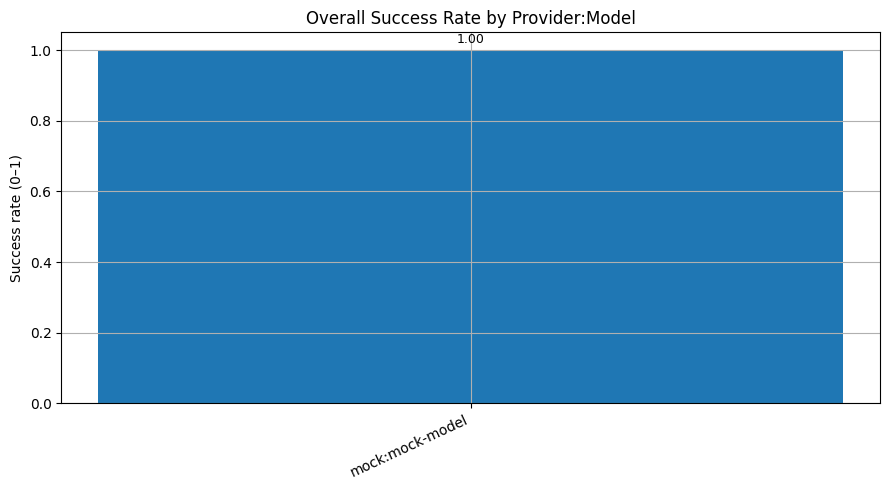

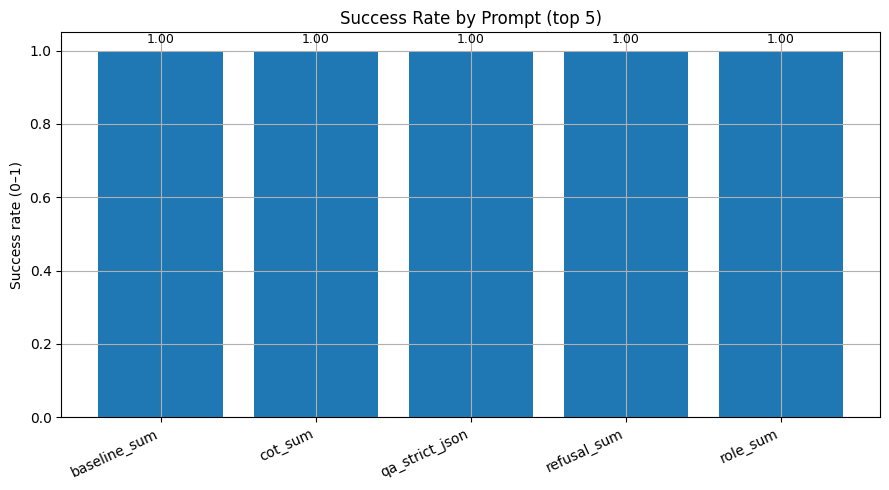

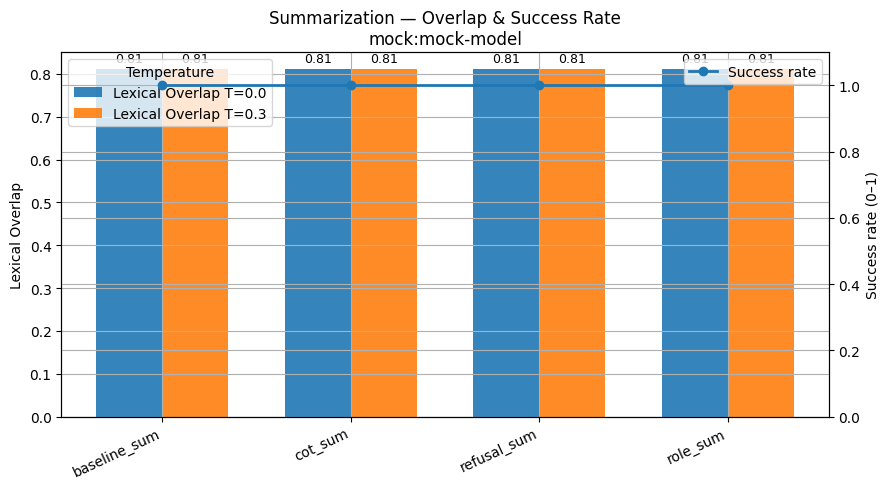

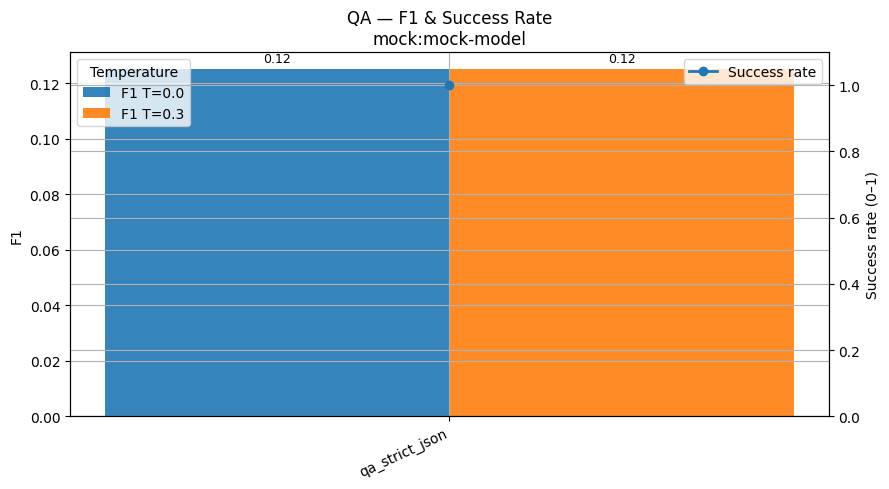

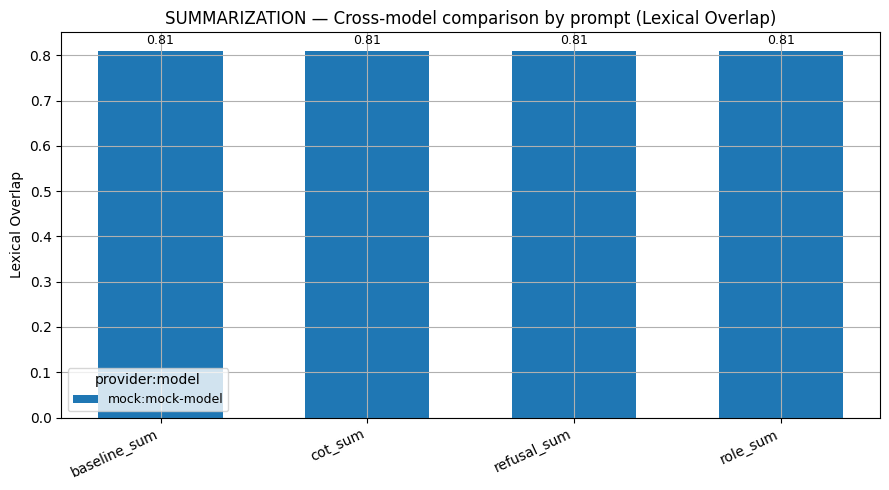

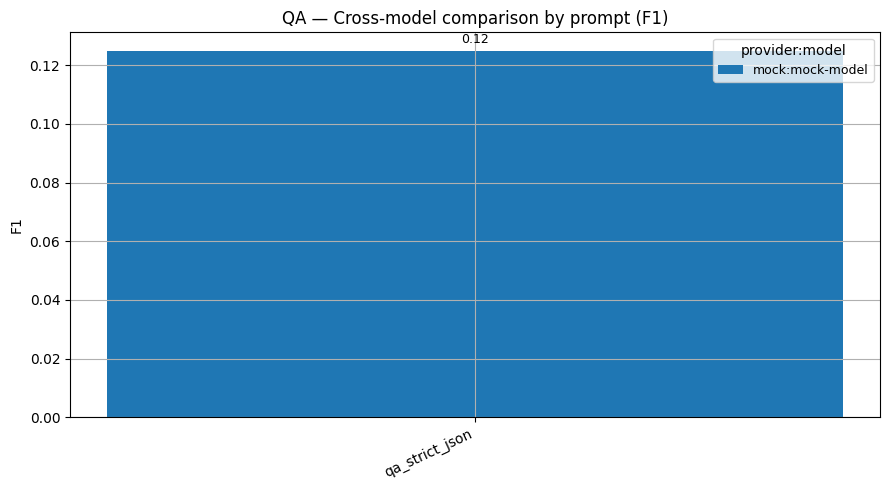

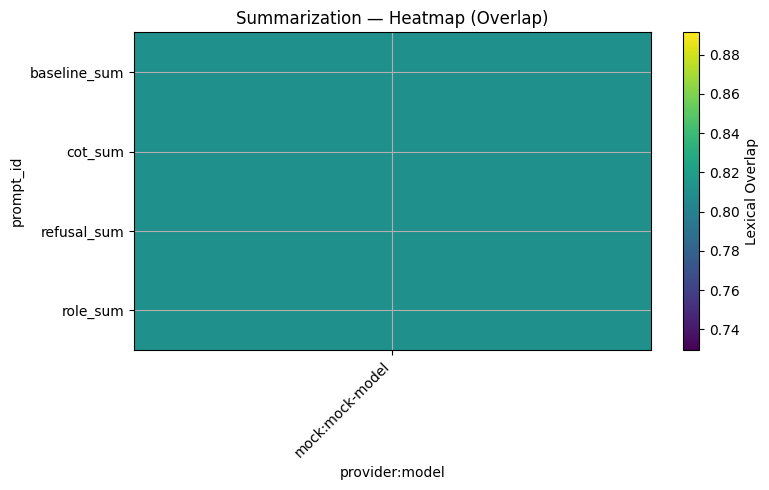

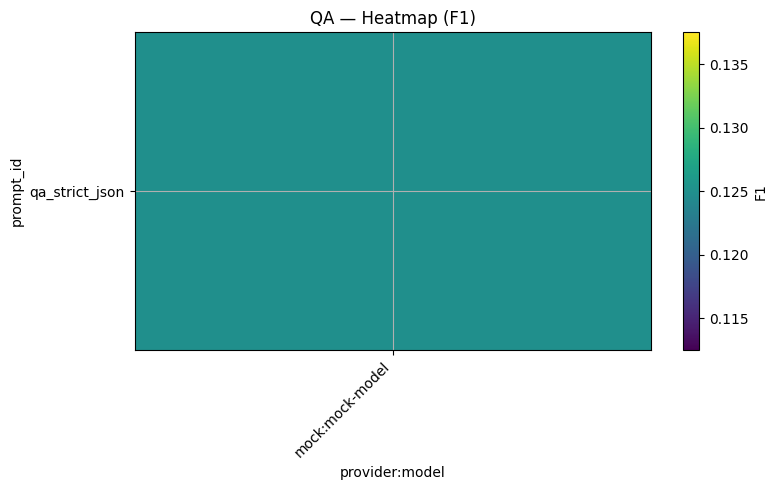

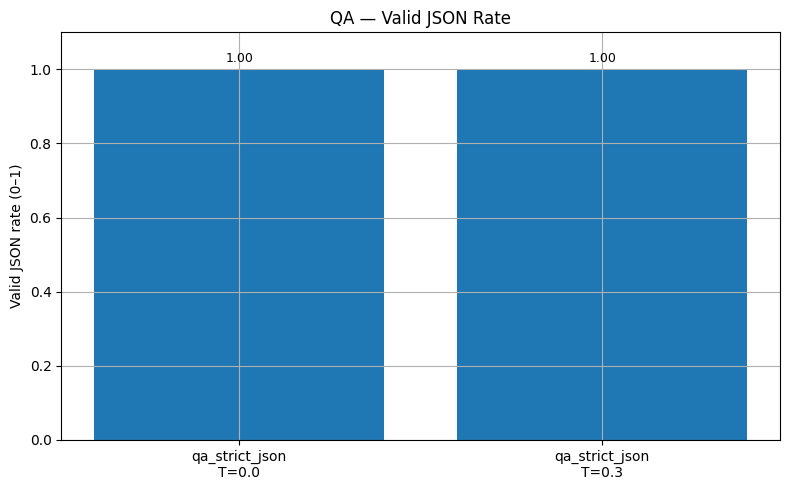


✅ Plotting complete.


In [24]:
# @title 10) Visualization: success rates, metric bars, cross-model, heatmaps
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter

assert 'df' in globals() and isinstance(df, pd.DataFrame) and len(df) > 0, "No df. Run experiments."
assert 'metrics' in globals() and isinstance(metrics, pd.DataFrame), "No metrics. Run evaluation."

plt.style.use("default")
plt.rcParams.update({"figure.figsize": (9,5), "axes.grid": True})

def autolabel(ax, rects):
    for r in rects:
        h = r.get_height()
        if np.isnan(h): continue
        ax.annotate(f"{h:.2f}", xy=(r.get_x()+r.get_width()/2, h),
                    xytext=(0,3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

print("=== Plotting diagnostics ===")
print("df rows:", len(df))
if "error" not in df.columns:
    df["error"] = False
succ_count = int((df["error"] == False).sum())
fail_count = int((df["error"] == True).sum())
print("Successful rows:", succ_count)
print("Failed rows:", fail_count)

errs = df[df["error"] == True]["output"].fillna("").astype(str)
if len(errs):
    print("\nTop error messages (up to 5):")
    for msg, cnt in Counter([e.splitlines()[0][:140] for e in errs]).most_common(5):
        print(f"• {cnt}×  {msg}")
else:
    print("\nNo error messages recorded.")

# 0) Success-rate plots
succ_overall = (df
    .assign(series=df.get("provider","unknown").astype(str)+":"+
                    df.get("model","unknown").astype(str))
    .groupby("series", dropna=False)["error"]
    .apply(lambda s: float((s==False).mean()))
    .reset_index(name="success_rate")
    .sort_values("success_rate", ascending=False))

if len(succ_overall):
    fig, ax = plt.subplots()
    x = np.arange(len(succ_overall))
    rects = ax.bar(x, succ_overall["success_rate"].values)
    autolabel(ax, rects)
    ax.set_title("Overall Success Rate by Provider:Model")
    ax.set_ylabel("Success rate (0–1)")
    ax.set_xticks(x)
    ax.set_xticklabels(succ_overall["series"].tolist(), rotation=25, ha="right")
    plt.tight_layout(); plt.show()

succ_by_prompt = (df.groupby(["prompt_id"], dropna=False)["error"]
                    .apply(lambda s: float((s==False).mean()))
                    .reset_index(name="success_rate")
                    .sort_values("success_rate", ascending=False))
if len(succ_by_prompt):
    topN = min(20, len(succ_by_prompt))
    fig, ax = plt.subplots()
    x = np.arange(topN)
    rects = ax.bar(x, succ_by_prompt["success_rate"].values[:topN])
    autolabel(ax, rects)
    ax.set_title(f"Success Rate by Prompt (top {topN})")
    ax.set_ylabel("Success rate (0–1)")
    ax.set_xticks(x)
    ax.set_xticklabels(succ_by_prompt["prompt_id"].values[:topN], rotation=25, ha="right")
    plt.tight_layout(); plt.show()

# 1) Metric bars per model (with success-rate overlay)
def plot_metric_bars(sub, value_col, title, ylabel):
    if not len(sub) or sub[value_col].notna().sum() == 0:
        print(f"[skip] No non-null values for {ylabel}.")
        return
    temps = sorted([t for t in sub["temperature"].dropna().unique()])
    order = list(sub["prompt_id"].unique())
    x = np.arange(len(order))
    width = 0.35 if len(temps)>1 else 0.6
    offsets = np.linspace(-width*(len(temps)-1)/2, width*(len(temps)-1)/2, max(len(temps),1))

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    if len(temps)==0:
        y = sub.set_index("prompt_id").reindex(order)[value_col].fillna(0.0).values
        rects = ax1.bar(x, y, width, alpha=0.9, label=ylabel)
        autolabel(ax1, rects)
    else:
        for i,T in enumerate(temps):
            s = sub[sub["temperature"]==T].set_index("prompt_id").reindex(order)
            y = s[value_col].fillna(0.0).values
            rects = ax1.bar(x+offsets[i], y, width, alpha=0.9, label=f"{ylabel} T={T}")
            autolabel(ax1, rects)
        ax1.legend(title="Temperature", loc="upper left")

    if "success_rate" in sub.columns:
       sr = (
        sub.groupby("prompt_id", dropna=False)["success_rate"]
           .mean()
           .reindex(order)
           .fillna(0.0)
           .values
    )

    ax2.plot(
        x,
        sr,
        marker="o",
        linewidth=2,
        label="Success rate"
    )

    ax2.set_ylabel("Success rate (0–1)")
    ax2.set_ylim(0, 1.1)
    ax2.legend(loc="upper right")

    ax1.set_title(title)
    ax1.set_ylabel(ylabel)
    ax1.set_xticks(x)
    ax1.set_xticklabels(order, rotation=25, ha="right")
    plt.tight_layout(); plt.show()

pairs = sorted({(r.provider, r.model) for r in metrics.itertuples()})
for (provider, model) in pairs:
    sub_sum = metrics[(metrics["task"]=="summarization") &
                      (metrics["provider"]==provider) &
                      (metrics["model"]==model)]
    plot_metric_bars(sub_sum, "sum_overlap_mean",
                     f"Summarization — Overlap & Success Rate\n{provider}:{model}",
                     "Lexical Overlap")

    sub_qa = metrics[(metrics["task"]=="qa") &
                     (metrics["provider"]==provider) &
                     (metrics["model"]==model)]
    plot_metric_bars(sub_qa, "f1_mean",
                     f"QA — F1 & Success Rate\n{provider}:{model}",
                     "F1")

# 2) Cross-model comparison (averaged over temps)
def plot_cross_model(task_name:str, metric_col:str, title_metric:str):
    sub = metrics[metrics["task"]==task_name].copy()
    if len(sub)==0 or sub[metric_col].notna().sum()==0:
        print(f"[{task_name}] No data for cross-model comparison.")
        return
    sub["series"] = sub["provider"] + ":" + sub["model"]
    avg = (sub.groupby(["prompt_id","series"], dropna=False)[metric_col].mean().reset_index())
    prompts = list(avg["prompt_id"].unique())
    series  = sorted(avg["series"].unique())
    x = np.arange(len(prompts))
    width = max(0.6 / max(len(series),1), 0.12)
    offsets = np.linspace(-width*(len(series)-1)/2, width*(len(series)-1)/2, len(series))

    fig, ax = plt.subplots()
    for i,s in enumerate(series):
        y = avg[avg["series"]==s].set_index("prompt_id").reindex(prompts)[metric_col].fillna(0.0).values
        rects = ax.bar(x+offsets[i], y, width, label=s)
        autolabel(ax, rects)
    ax.set_title(f"{task_name.upper()} — Cross-model comparison by prompt ({title_metric})")
    ax.set_ylabel(title_metric); ax.set_xticks(x); ax.set_xticklabels(prompts, rotation=25, ha="right")
    ax.legend(title="provider:model", fontsize=9)
    plt.tight_layout(); plt.show()

plot_cross_model("summarization", "sum_overlap_mean", "Lexical Overlap")
plot_cross_model("qa",            "f1_mean",         "F1")

# 3) Heatmaps
def heatmap_prompt_model(sub, metric_col, title_metric, title):
    if not len(sub) or sub[metric_col].notna().sum()==0:
        print(f"[skip] Heatmap: no non-null {metric_col}.")
        return
    sub = sub.copy()
    sub["series"] = sub["provider"] + ":" + sub["model"]
    pivot = (sub.groupby(["prompt_id","series"], dropna=False)[metric_col]
               .mean().unstack("series")).fillna(0.0)
    prompts = list(pivot.index)
    series  = list(pivot.columns)
    Z = pivot.values
    fig, ax = plt.subplots(figsize=(max(8, len(series)*0.6), max(5, len(prompts)*0.3)))
    im = ax.imshow(Z, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("provider:model"); ax.set_ylabel("prompt_id")
    ax.set_xticks(np.arange(len(series))); ax.set_xticklabels(series, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(prompts))); ax.set_yticklabels(prompts)
    cbar = plt.colorbar(im, ax=ax); cbar.set_label(title_metric)
    plt.tight_layout(); plt.show()

heatmap_prompt_model(metrics[metrics["task"]=="summarization"], "sum_overlap_mean",
                     "Lexical Overlap", "Summarization — Heatmap (Overlap)")
heatmap_prompt_model(metrics[metrics["task"]=="qa"], "f1_mean",
                     "F1", "QA — Heatmap (F1)")

# 4) QA JSON validity rate
if "json_valid_rate" in metrics.columns:
    qa_json = metrics[
        (metrics["task"] == "qa") &
        (metrics["json_valid_rate"].notna())
    ].copy()

    if len(qa_json):
        labels = [
            f"{p}\nT={t}"
            for p, t in zip(qa_json["prompt_id"], qa_json["temperature"])
        ]

        fig, ax = plt.subplots(figsize=(8, 5))
        x = np.arange(len(qa_json))

        rects = ax.bar(x, qa_json["json_valid_rate"].values)
        autolabel(ax, rects)

        ax.set_title("QA — Valid JSON Rate")
        ax.set_ylabel("Valid JSON rate (0–1)")
        ax.set_ylim(0, 1.1)
        ax.set_xticks(x)
        ax.set_xticklabels(labels)

        plt.tight_layout()
        plt.show()

print("\n✅ Plotting complete.")

In [25]:
# @title 11) Human-eval sample & submission checklist
import pandas as pd, glob, os

# Sample 30 diverse rows for manual rating (Correctness, Completeness, Clarity, Hallucination)
sample = (df.sample(min(30, len(df)), random_state=42)
            [["id","task","provider","model","prompt_id","temperature",
              "input","question","context","output","reference"]])
human_csv = f"/content/results/human_eval_sample_{stamp}.csv"
sample.to_csv(human_csv, index=False)
print("Saved human-eval sample:", human_csv)

print("\nArtifacts saved under /content/results:")
for p in sorted(glob.glob("/content/results/*")):
    print(" •", os.path.basename(p))

print("""
WHAT TO SUBMIT:
- results/outputs_*.csv   (raw generations)
- results/metrics_*.csv   (automatic metrics per condition)
- results/human_eval_sample_*.csv  (for your rating sheet)
- A 2–3 page PDF reflection:
  • Abstract (≤150 words)
  • Methods (tasks, data, prompts, params, models)
  • Results (tables/plots; significant differences; cost/latency if applicable)
  • Error analysis & hallucination audit (labeled examples)
  • Ethics & limitations (risks, mitigations, threats to validity)
  • Takeaways (3–5 practitioner lessons)
""")

Saved human-eval sample: /content/results/human_eval_sample_20261008_233921.csv

Artifacts saved under /content/results:
 • human_eval_sample_20261008_233921.csv
 • metrics_20261008_233921.csv
 • outputs_20261008_233921.csv

WHAT TO SUBMIT:
- results/outputs_*.csv   (raw generations)
- results/metrics_*.csv   (automatic metrics per condition)
- results/human_eval_sample_*.csv  (for your rating sheet)
- A 2–3 page PDF reflection:
  • Abstract (≤150 words)
  • Methods (tasks, data, prompts, params, models)
  • Results (tables/plots; significant differences; cost/latency if applicable)
  • Error analysis & hallucination audit (labeled examples)
  • Ethics & limitations (risks, mitigations, threats to validity)
  • Takeaways (3–5 practitioner lessons)

